# 06 – Results Visualization
In questo notebook raccolgo le figure finali da inserire nella tesi e ne supporto l'interpretazione clinica. L'obiettivo non è solo produrre grafici esteticamente puliti, ma mostrare in modo leggibile come i pattern di movimento e la risposta cardiaca cambiano tra test diversi e come queste differenze si riflettano sulle prestazioni dei modelli.

Dal punto di vista narrativo, queste figure collegano i tre obiettivi del lavoro: comportamento fisiologico durante i test, capacità discriminativa delle feature e qualità finale della classificazione. Per questo ogni grafico va letto come parte di una storia unica e non come immagine isolata.


In [1]:
import sys; sys.path.insert(0, '..')  # Consento al notebook di richiamare configurazioni e utility del progetto
import warnings; warnings.filterwarnings('ignore')  # Nascondo warning non essenziali per focalizzarmi sull'output grafico finale
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid', font_scale=1.1)  # Aumento leggermente il font per ottenere figure più leggibili in tesi
%matplotlib inline
full_df = pd.read_csv('../results/tables/features_all.csv')  # Carico la tabella unica da cui derivano tutti i grafici comparativi


## 1. R-R interval vs. tipo di attività (box plot)
Questo box plot permette di confrontare come varia l'intervallo R-R medio tra i diversi test motori. Dal punto di vista fisiologico, attività più intense o continue dovrebbero tendere a mostrare valori di R-R più bassi, quindi frequenza cardiaca più elevata.

L'interesse non è solo la mediana, ma anche la dispersione: una variabilità ampia può riflettere eterogeneità inter-paziente, differenze di intensità esecutiva oppure diversa tolleranza allo sforzo durante la riabilitazione.


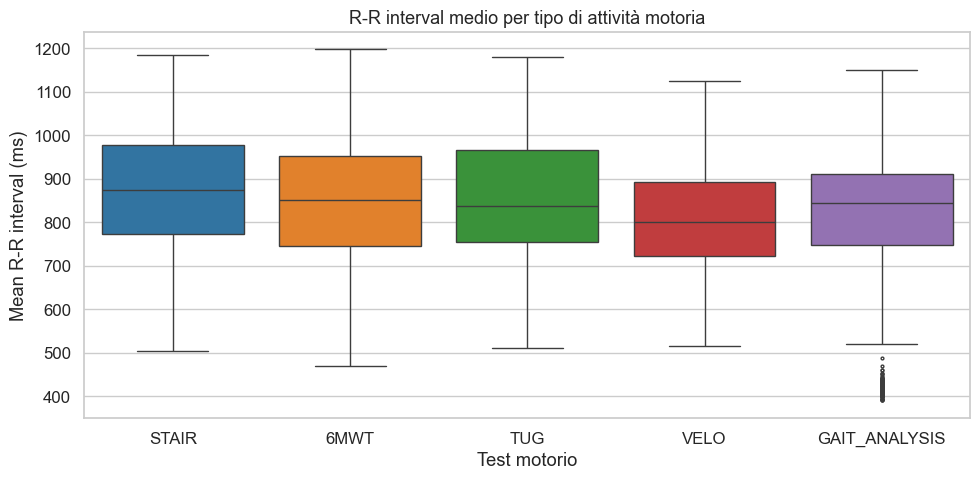

In [2]:
from src.config import TEST_LABELS
fig, ax = plt.subplots(figsize=(10, 5))
order = TEST_LABELS  # Impongo un ordine coerente dei test per rendere confrontabili tutte le figure del notebook
sub = full_df[full_df['test_label'].isin(order)]  # Tengo solo le prove motorie d'interesse per evitare etichette spurie nel grafico finale
sns.boxplot(data=sub, x='test_label', y='ecg_mean_rr', order=order,
    palette='tab10', fliersize=2, ax=ax)  # Il box plot evidenzia sia la tendenza centrale sia la presenza di valori estremi plausibili in dati clinici reali
ax.set_title('R-R interval medio per tipo di attività motoria', fontsize=13)
ax.set_xlabel('Test motorio'); ax.set_ylabel('Mean R-R interval (ms)')
plt.tight_layout()
plt.savefig('../results/figures/rr_by_activity.png', dpi=200)  # Esporto la figura ad alta risoluzione per l'inserimento in tesi
plt.show()


## 2. HR medio vs. tipo di attività
Qui rappresento la stessa informazione fisiologica in termini di **frequenza cardiaca media**, che spesso è più immediata da discutere in ambito clinico. Se il box plot precedente mostrava R-R più bassi, qui mi aspetto coerentemente HR più alti per le attività più impegnative.

L'uso del violin plot aggiunge una lettura della densità: questo aiuta a capire se una stessa attività presenta un comportamento abbastanza omogeneo oppure sottogruppi di pazienti con risposte cardiovascolari diverse.


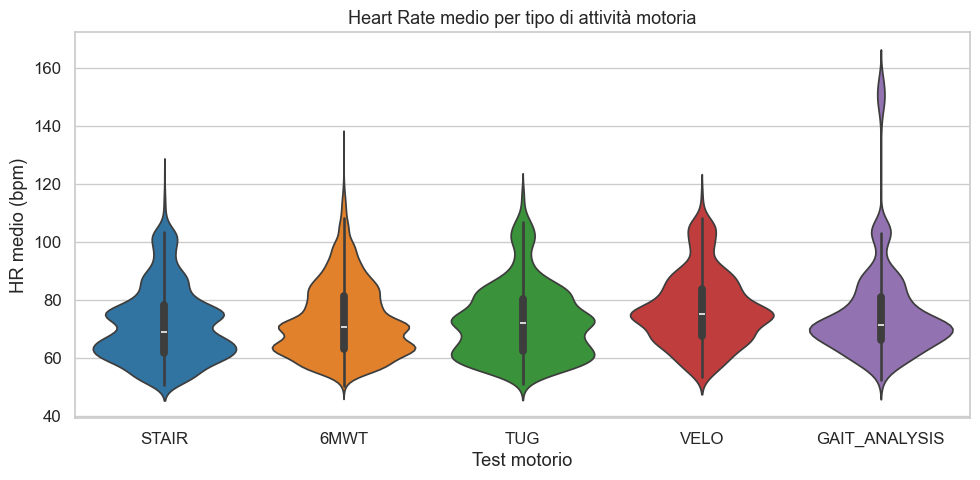

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(data=sub, x='test_label', y='ecg_hr_mean', order=order,
    palette='tab10', ax=ax, inner='box')  # Il violin plot combina distribuzione e sintesi robusta, utile quando i pazienti non rispondono in modo uniforme allo sforzo
ax.set_title('Heart Rate medio per tipo di attività motoria', fontsize=13)
ax.set_xlabel('Test motorio'); ax.set_ylabel('HR medio (bpm)')
plt.tight_layout()
plt.savefig('../results/figures/hr_by_activity.png', dpi=200)  # Salvo la figura perché il confronto HR è centrale nella discussione fisiologica
plt.show()


## 3. ACC magnitudine vs tipo di attività
Questo grafico sposta l'attenzione dal cuore al movimento vero e proprio. La magnitudine media dell'accelerazione è una misura intuitiva dell'intensità meccanica del gesto e dovrebbe differenziare bene attività come cammino, scale o cyclette.

Confrontare questa figura con quelle ECG è utile perché permette di vedere se maggiore intensità motoria si accompagna anche a maggiore attivazione cardiovascolare. In pratica, sto cercando coerenza tra il "carico esterno" misurato dall'ACC e il "carico interno" osservato nell'ECG.


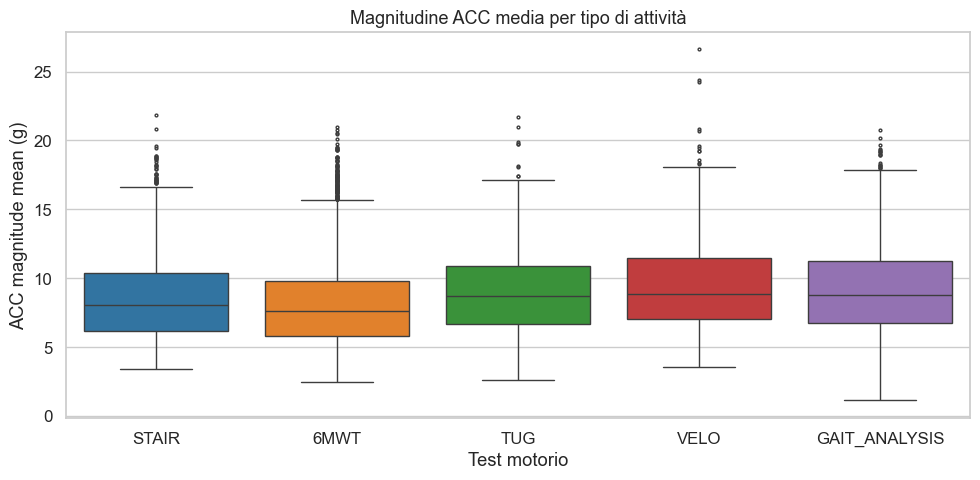

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=sub, x='test_label', y='acc_mag_mean', order=order,
    palette='tab10', fliersize=2, ax=ax)  # Uso ancora il box plot perché rende immediato il confronto dell'intensità motoria tra test diversi
ax.set_title('Magnitudine ACC media per tipo di attività', fontsize=13)
ax.set_xlabel('Test motorio'); ax.set_ylabel('ACC magnitude mean (g)')
plt.tight_layout()
plt.savefig('../results/figures/acc_mag_by_activity.png', dpi=200)  # Questa figura è utile per collegare le differenze di movimento ai risultati di classificazione
plt.show()


## 4. Scatter: SMA vs Mean R-R per test
Lo scatter tra **Signal Magnitude Area (SMA)** e **mean R-R** visualizza direttamente il rapporto tra quantità di movimento e risposta cardiaca. Mi aspetto un andamento mediamente negativo: quando il paziente si muove di più, l'attivazione simpatica aumenta, la FC cresce e l'intervallo R-R tende a ridursi.

Questa figura è importante anche perché rende intuitiva la correlazione già vista nel notebook precedente: non solo un numero sintetico, ma una nube di punti da interpretare con occhio fisiologico.


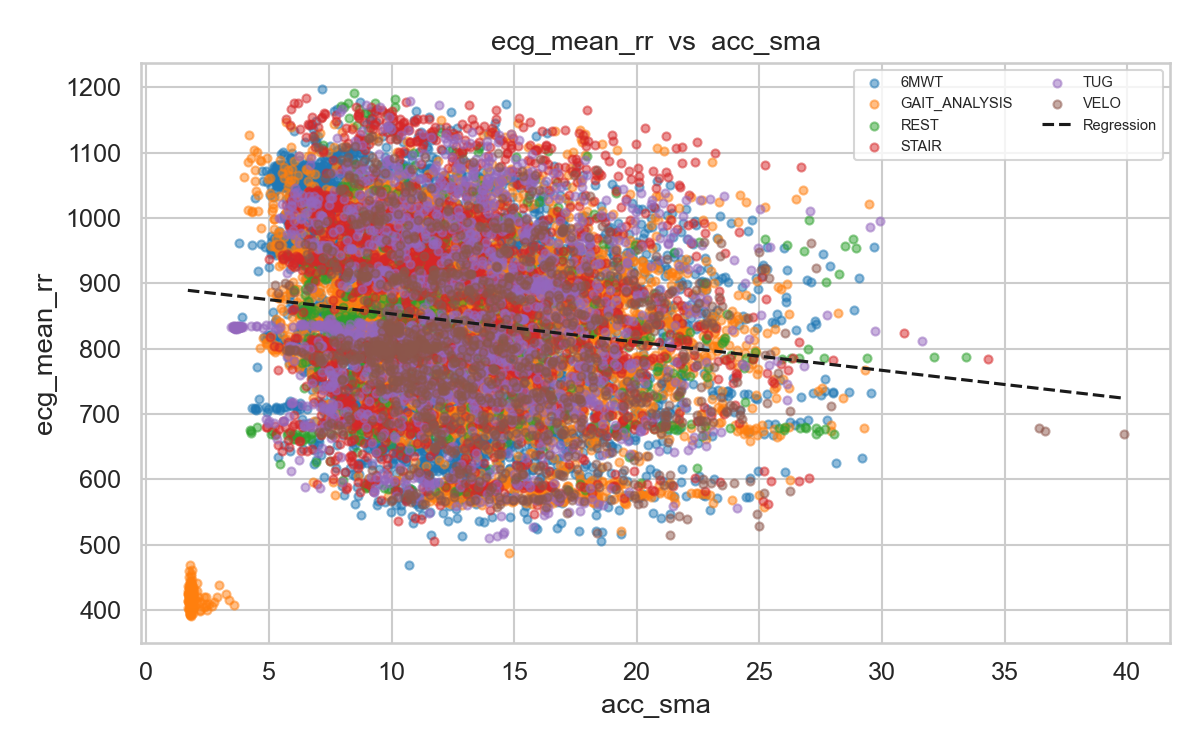

In [5]:
from src.correlation_analysis import plot_scatter_regression
plot_scatter_regression(full_df, x_col='acc_sma', y_col='ecg_mean_rr',
    output_path='../results/figures/scatter_sma_rr.png')  # Salvo uno scatter con regressione per visualizzare insieme dispersione e trend medio
from IPython.display import Image; Image('../results/figures/scatter_sma_rr.png')  # Mostro il file realmente esportato, così verifico che la figura pronta per la tesi sia corretta


## 5. Confronto modelli — Obiettivo 1
Questo confronto sintetizza le prestazioni dei modelli nei task di classificazione. Il grafico rende subito evidente che la **Random Forest** è il modello più solido per il riconoscimento del tipo di attività e che il task binario REST vs ACTIVITY è più semplice del multiclass, come confermato dai valori di weighted F1.

Dal punto di vista interpretativo, il confronto tra F1 è preferibile alla sola accuracy perché penalizza meglio gli errori distribuiti in modo non uniforme tra classi. In tesi, questa figura aiuta a giustificare sia la scelta del modello finale sia la diversa difficoltà dei due obiettivi.


In [6]:
import pandas as pd
obj1 = pd.read_csv('../results/tables/obj1_activity_type.csv')  # Recupero le metriche salvate per il task multiclass
obj2 = pd.read_csv('../results/tables/obj2_effort.csv')  # Recupero le metriche del task binario REST vs ACTIVITY
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, df, title in [(axes[0], obj1, 'Tipo attività'), (axes[1], obj2, 'Livello sforzo')]:
    bars = ax.bar(df['model'], df['weighted_f1'], color=sns.color_palette('tab10', 3), edgecolor='white')  # Metto a confronto la weighted F1 perché è la metrica più informativa per classi non perfettamente bilanciate
    ax.set_ylim(0, 1); ax.set_ylabel('Weighted F1-score')
    ax.set_title(f'Classificazione — {title}', fontsize=12)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)  # Scrivo il valore sopra ogni barra per facilitare la lettura numerica immediata
plt.tight_layout()
plt.savefig('../results/figures/model_comparison.png', dpi=200)  # Salvo una figura riassuntiva molto utile nella sezione risultati
plt.show()


## 6. Confusion matrix — best model (Obiettivo 1)
Le confusion matrix sono fondamentali perché mostrano **dove** il modello sbaglia, non solo quanto sbaglia in media. In un problema multiclass come questo, capire quali attività vengono confuse tra loro è spesso più informativo della metrica globale: ad esempio, errori tra test motori con richieste biomeccaniche simili sono più comprensibili di errori completamente casuali.

Clinicamente, una matrice di confusione ben leggibile aiuta a discutere i limiti del sistema: se due test producono pattern vicini, il risultato suggerisce che il comportamento fisiologico e motorio dei pazienti può sovrapporsi almeno in alcune finestre temporali.


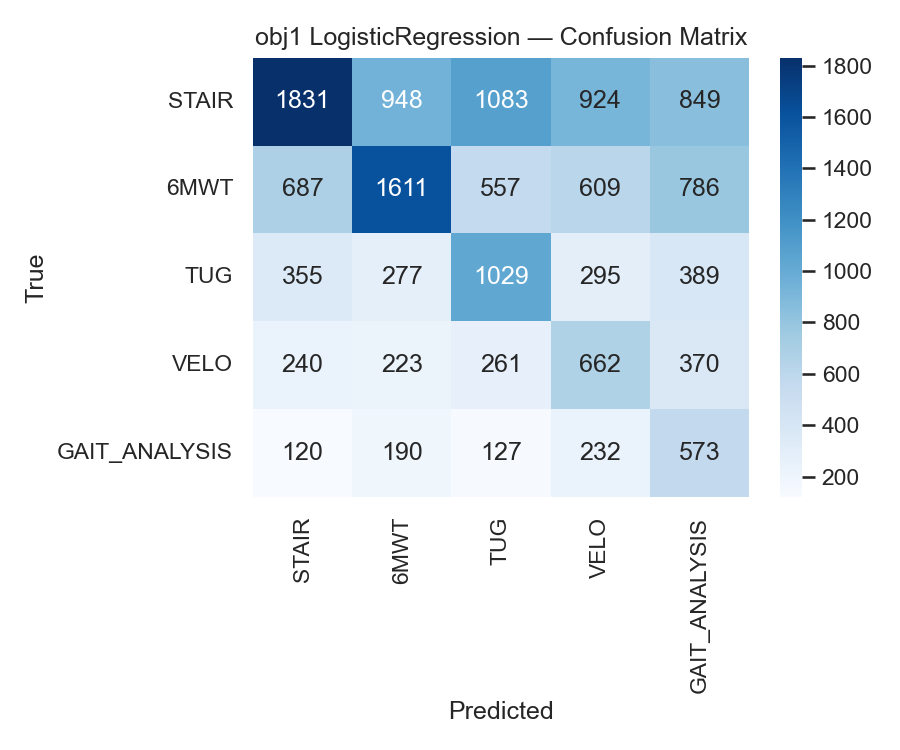

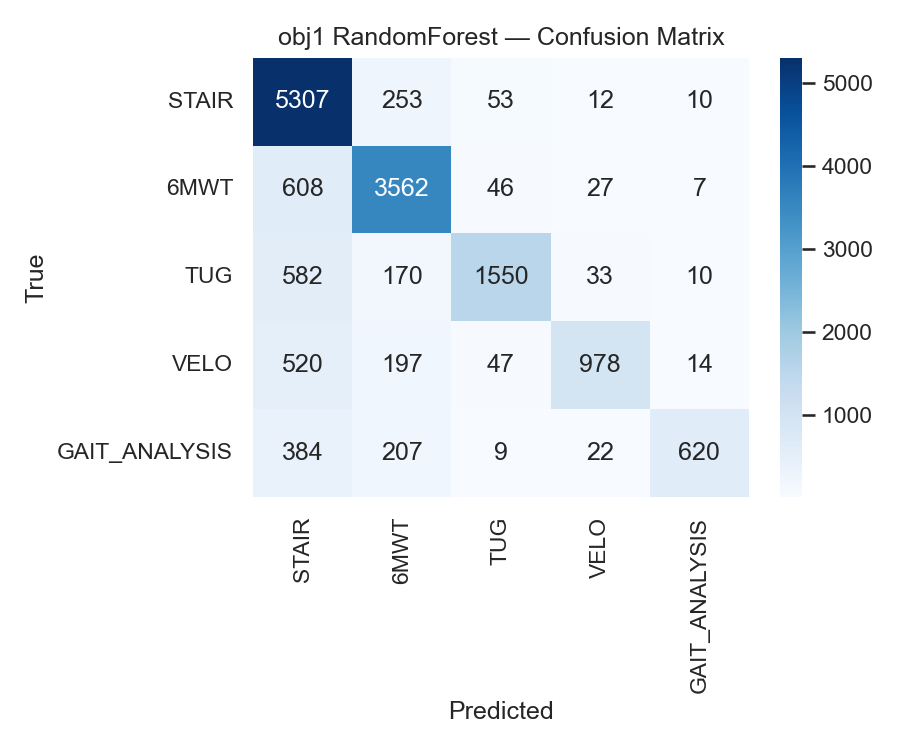

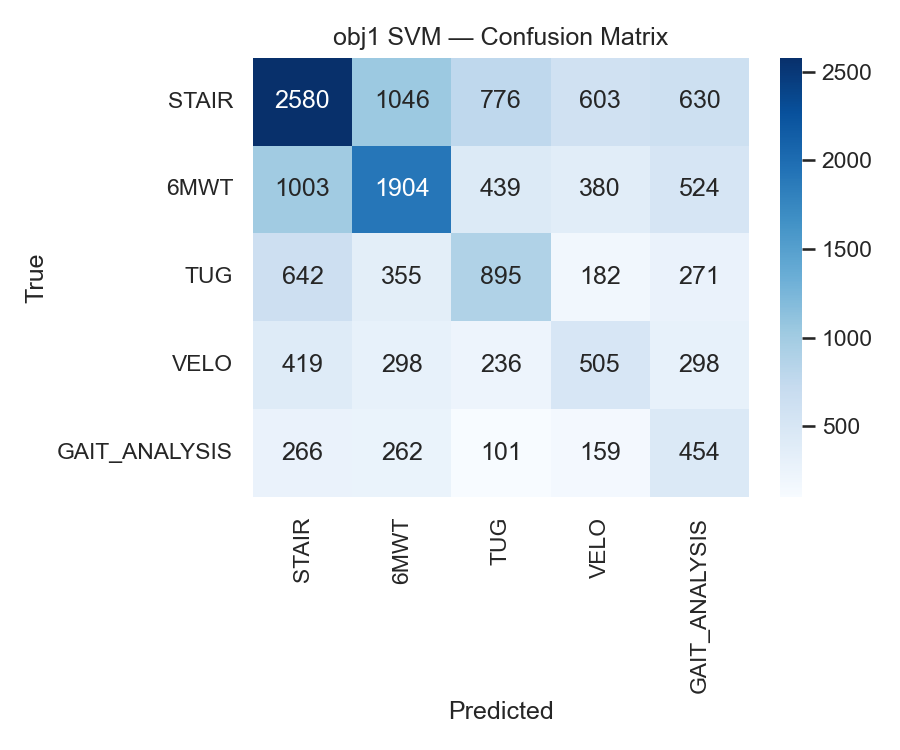

In [7]:
from IPython.display import Image
import os
imgs = sorted([f for f in os.listdir('../results/figures') if f.startswith('obj1') and f.endswith('_cm.png')])  # Recupero tutte le matrici salvate per confrontare rapidamente i modelli del task 1
for img in imgs:
    display(Image(f'../results/figures/{img}'))  # Visualizzo le immagini esportate perché sono quelle effettivamente utilizzabili nel documento finale
